In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("/content/drive/MyDrive/customer_churn_dataset-training-master.csv")

In [6]:
df.shape

(440833, 12)

In [7]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [8]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


## Box plot - check Outliers

In [10]:
df.head(100)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,104.0,26.0,Male,15.0,11.0,0.0,20.0,Basic,Annual,269.0,1.0,1.0
96,105.0,58.0,Female,28.0,17.0,0.0,24.0,Premium,Quarterly,820.0,29.0,1.0
97,106.0,56.0,Female,16.0,11.0,5.0,18.0,Premium,Monthly,590.0,27.0,1.0
98,107.0,42.0,Female,12.0,6.0,8.0,25.0,Basic,Monthly,566.0,11.0,1.0


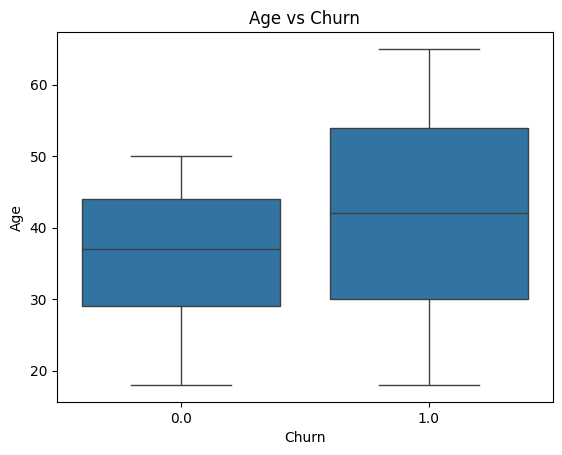

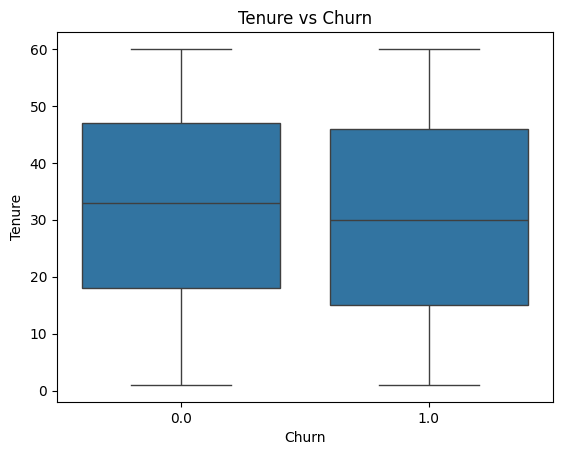

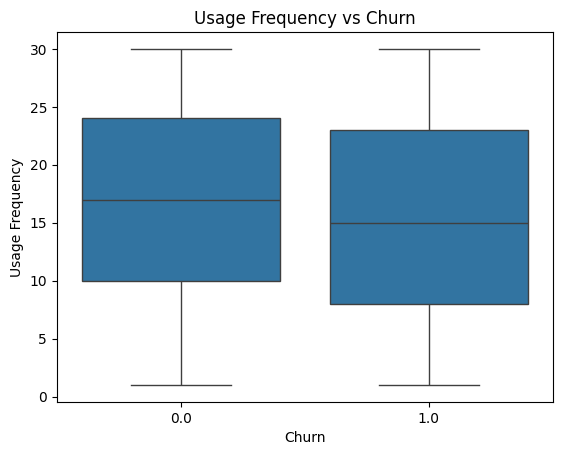

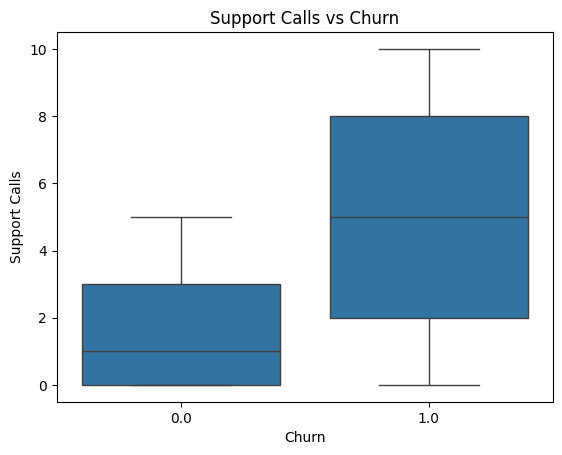

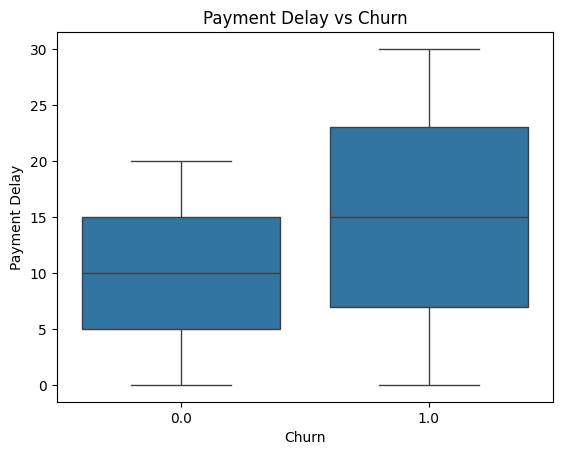

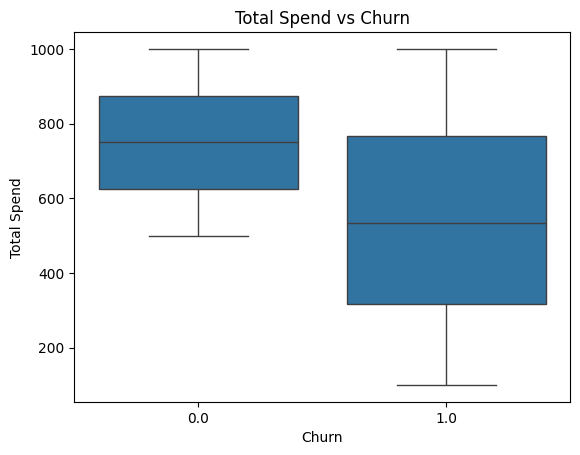

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend']

for col in num_cols:
  sns.boxplot(x='Churn',y=col, data=df)
  plt.title(f'{col} vs Churn')
  plt.show()

## Target distribution

In [12]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
1.0,0.567107
0.0,0.432893


## Categorical analysis

In [13]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

for col in cat_cols:
    churn_rate = df.groupby(col)['Churn'].mean()
    print("\n", col)
    print(churn_rate)


 Gender
Gender
Female    0.666691
Male      0.491269
Name: Churn, dtype: float64

 Subscription Type
Subscription Type
Basic       0.581782
Premium     0.559417
Standard    0.560700
Name: Churn, dtype: float64

 Contract Length
Contract Length
Annual       0.460761
Monthly      1.000000
Quarterly    0.460256
Name: Churn, dtype: float64


## Numerical features vs churn

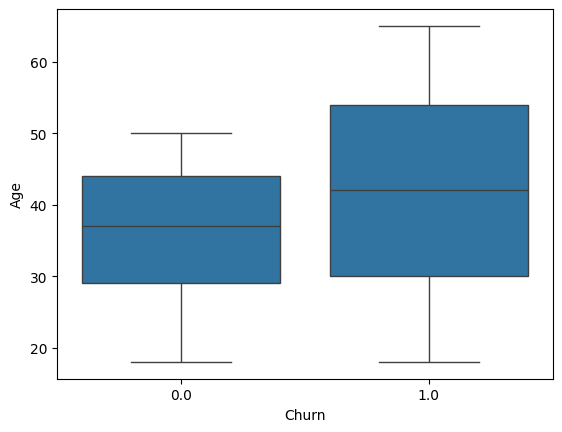

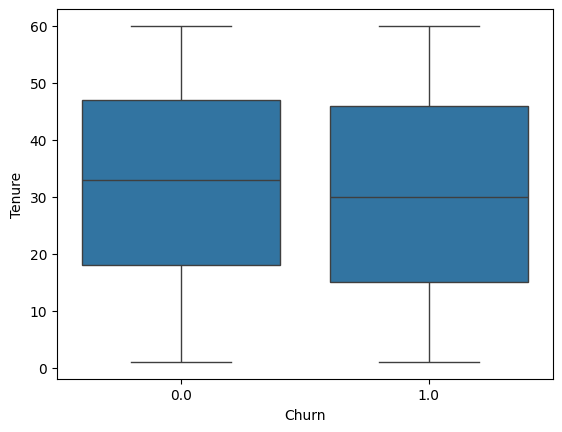

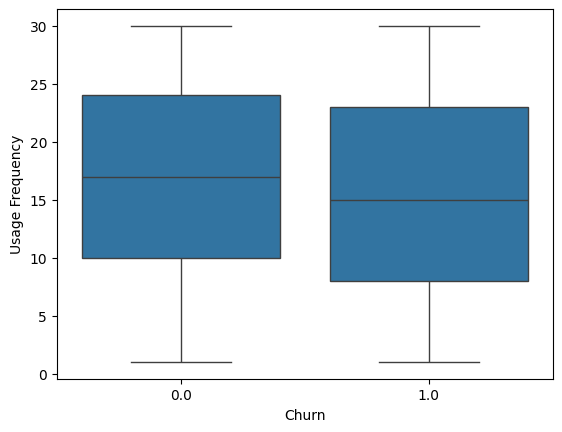

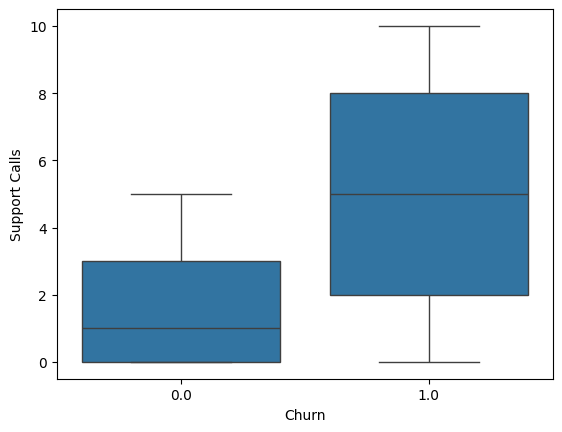

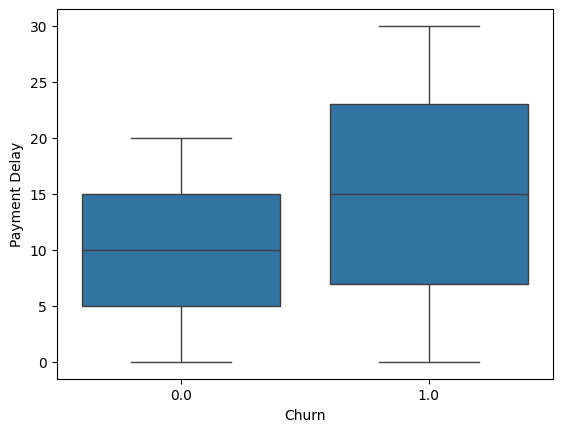

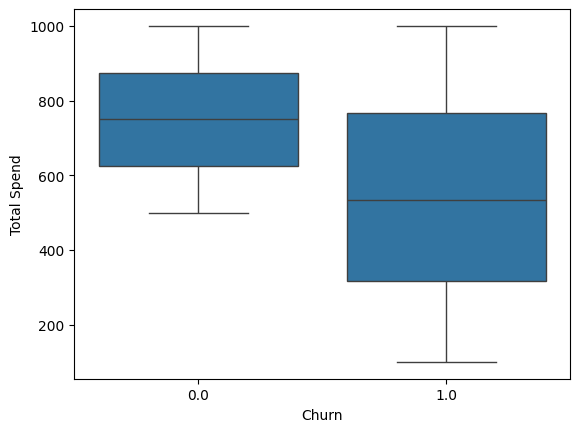

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend']

for col in num_cols:
    sns.boxplot(x='Churn', y=col, data=df)
    plt.show()

## Correlation

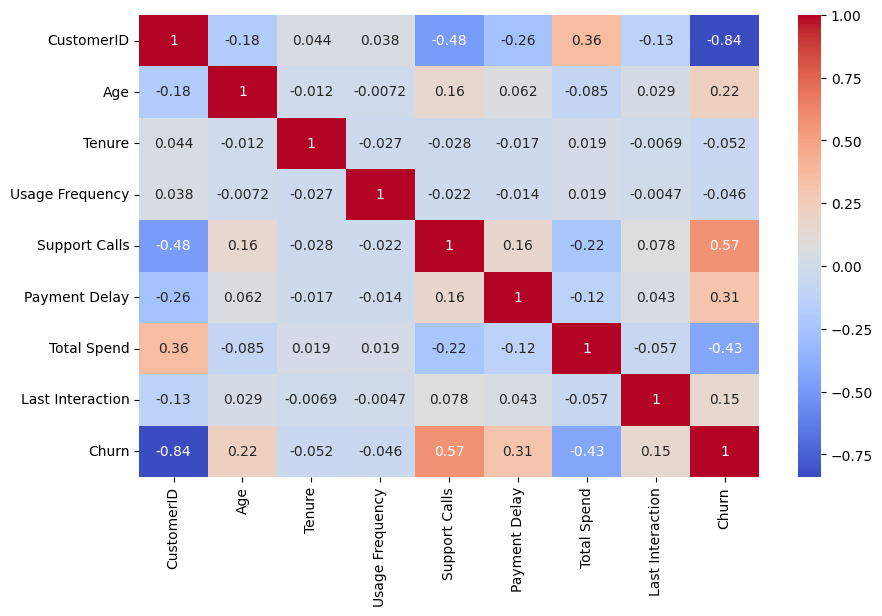

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.savefig('correlation.png')
plt.show()

## Preprocessing

In [16]:
df.drop(columns=['CustomerID'], inplace=True)

In [17]:
df = pd.get_dummies(df, drop_first=True)

In [18]:
print(df['Churn'].value_counts())

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64


In [19]:
df.isnull().sum()

,0
Age,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Total Spend,1
Last Interaction,1
Churn,1
Gender_Male,0
Subscription Type_Premium,0


In [20]:
df.dropna()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.00,17.0,1.0,False,False,True,False,False
1,65.0,49.0,1.0,10.0,8.0,557.00,6.0,1.0,False,False,False,True,False
2,55.0,14.0,4.0,6.0,18.0,185.00,3.0,1.0,False,False,False,False,True
3,58.0,38.0,21.0,7.0,7.0,396.00,29.0,1.0,True,False,True,True,False
4,23.0,32.0,20.0,5.0,8.0,617.00,20.0,1.0,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,54.0,15.0,1.0,3.0,716.38,8.0,0.0,True,True,False,False,False
440829,25.0,8.0,13.0,1.0,20.0,745.38,2.0,0.0,False,True,False,False,False
440830,26.0,35.0,27.0,1.0,5.0,977.31,9.0,0.0,True,False,True,False,True
440831,28.0,55.0,14.0,2.0,0.0,602.55,2.0,0.0,True,False,True,False,True


## MODEL TRAINING

In [21]:
# 1. Clean df first
df = df.dropna()

# 2. Reset index
df = df.reset_index(drop=True)

# 3. Then create X and y
X = df.drop('Churn', axis=1)
y = df['Churn']

In [22]:
from sklearn.model_selection import train_test_split

# 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

### Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

### XGBoost

In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=3)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

### SHAP

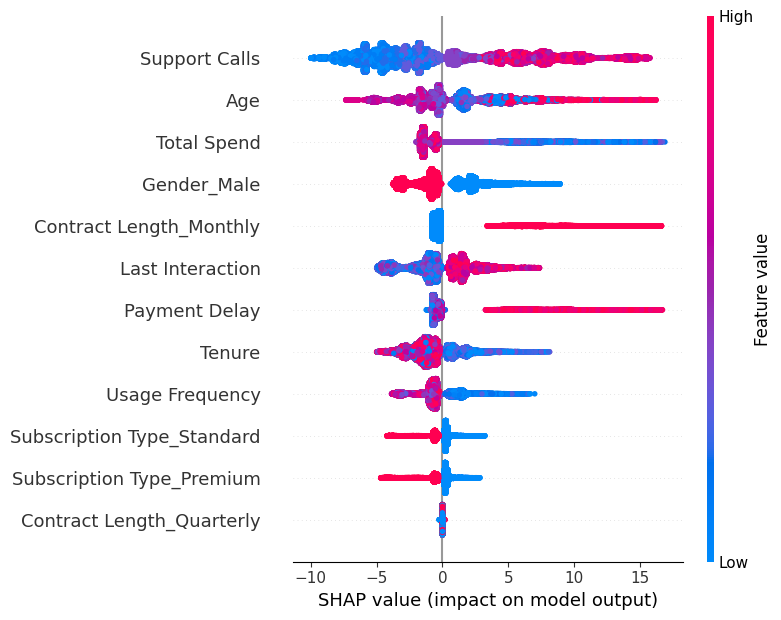

In [28]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('shap.png')